In [8]:
import pandas as pd

df1 = pd.read_csv("training.csv")
df2 = pd.read_csv("testing.csv")

In [9]:
len(df1.columns), len(df2.columns)

(133, 133)

# Random Forest Classifier Algorithm

In [2]:
import pandas as pd
import numpy as np
import pickle, warnings, json
warnings.filterwarnings('ignore')
 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
# ── 1. Load data ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  DISEASE PREDICTION MODEL  —  Random Forest Classifier")
print("=" * 65)
 
train_df = pd.read_csv('./Training.csv')
test_df  = pd.read_csv('./Testing.csv')
 
# Drop trailing empty columns if any
train_df = train_df.loc[:, ~train_df.columns.str.match(r'Unnamed')]
test_df  = test_df.loc[:,  ~test_df.columns.str.match(r'Unnamed')]
 
# Strip whitespace from column names
train_df.columns = train_df.columns.str.strip()
test_df.columns  = test_df.columns.str.strip()
 
print(f"\n📂  Training set : {train_df.shape[0]} rows × {train_df.shape[1]} columns")
print(f"📂  Testing set  : {test_df.shape[0]}  rows × {test_df.shape[1]} columns")
 
# ── 2. Split features / target ───────────────────────────────────────────────
TARGET = 'prognosis'
FEATURES = [c for c in train_df.columns if c != TARGET]
 
X_train = train_df[FEATURES]
y_train = train_df[TARGET].str.strip()
 
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET].str.strip()
 
print(f"\n🔬  Feature columns : {len(FEATURES)}")
print(f"🏷️   Unique diseases  : {y_train.nunique()}")
print(f"\n📊  Disease distribution (Training):")
vc = y_train.value_counts()
for disease, count in vc.items():
    print(f"    {disease:<45} {count:>4} samples")
 

  DISEASE PREDICTION MODEL  —  Random Forest Classifier

📂  Training set : 4920 rows × 133 columns
📂  Testing set  : 42  rows × 133 columns

🔬  Feature columns : 132
🏷️   Unique diseases  : 41

📊  Disease distribution (Training):
    Fungal infection                               120 samples
    Allergy                                        120 samples
    GERD                                           120 samples
    Chronic cholestasis                            120 samples
    Drug Reaction                                  120 samples
    Peptic ulcer diseae                            120 samples
    AIDS                                           120 samples
    Diabetes                                       120 samples
    Gastroenteritis                                120 samples
    Bronchial Asthma                               120 samples
    Hypertension                                   120 samples
    Migraine                                       120 samples
    Cervical s

In [ ]:
# ── 3. Train model ───────────────────────────────────────────────────────────
print("\n⚙️   Training Random Forest (200 trees)...")
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("✅  Training complete!")

# Save model to eleminate re-training on every request
with open("../model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save columns separately
with open("../columns.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)

print("✅ Model & columns saved successfully!")


⚙️   Training Random Forest (200 trees)...
✅  Training complete!
✅ Model & columns saved successfully!


In [4]:
y_pred = model.predict(X_test)
 
train_acc = model.score(X_train, y_train)
test_acc  = accuracy_score(y_test, y_pred)
 
print("\n" + "=" * 65)
print("  MODEL ACCURACY")
print("=" * 65)
print(f"  Training Accuracy : {train_acc * 100:.2f}%")
print(f"  Testing  Accuracy : {test_acc  * 100:.2f}%")
print("=" * 65)
 
print("\n" + "=" * 65)
print("  MODEL EVALUATION REPORT (TEST SET)")
print(model.score(X_train, y_train), model.score(X_test, y_test))


  MODEL ACCURACY
  Training Accuracy : 100.00%
  Testing  Accuracy : 97.62%

  MODEL EVALUATION REPORT (TEST SET)
1.0 0.9761904761904762


In [ ]:
new_df = pd.read_csv('./updated_randomized_dataset.csv')
new_df.shape

new_X = new_df.drop('prognosis', axis=1)
new_y = new_df['prognosis']

# new_pred = model.predict(new_X)
print(model.score(new_X, new_y))


0.9483739837398374


In [7]:
# loading the datasets for testing
df1= pd.read_csv("./Testing.csv")
df2 = pd.read_csv("./Testing_2.csv")
df3 = pd.read_csv("./updated_randomized_dataset.csv")

df1.shape, df2.shape, df3.shape


((42, 133), (4920, 133), (2460, 133))

```
remove first column of df3 and save to .csv
df3 = df3[df3.columns[1:]]
df3.to_csv("./updated_randomized_dataset.csv", index=False)
```

In [8]:
# score of the model for each dataset

print("------------- testing model ----------")
X = df1.drop(['prognosis'], axis=1)
y = df1['prognosis']

print(model.score(X, y))

print("------------- Testing 2 model ----------")
X = df2.drop(['prognosis'], axis=1)
y = df2['prognosis']

print(model.score(X, y))

print("------------- updated Randomized  model ----------")
X = df3.drop(['prognosis'], axis=1)
y = df3['prognosis']

print(model.score(X, y))

------------- testing model ----------
0.9285714285714286
------------- Testing 2 model ----------
0.9512195121951219
------------- updated Randomized  model ----------
0.9483739837398374


# Visualization

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# vs code setting
%matplotlib inline

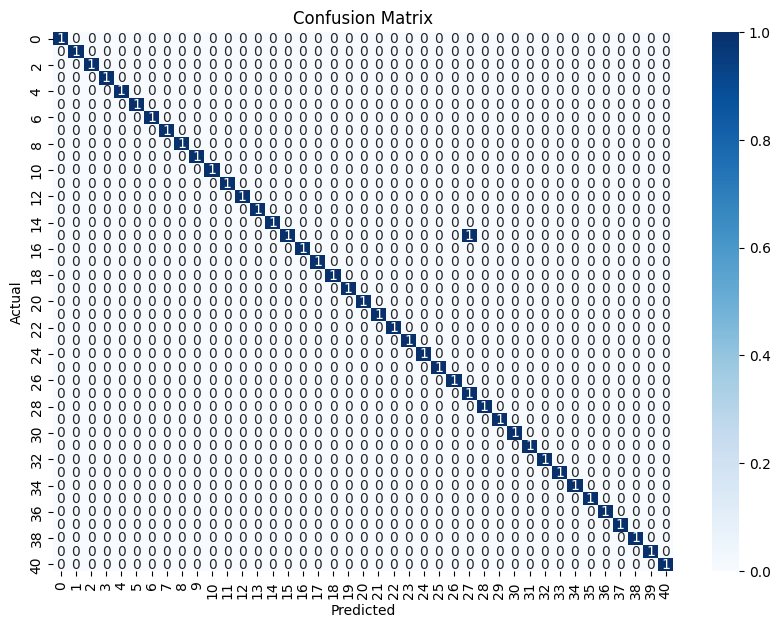

In [20]:
# 2. Confusion Matrix - This helps you see where your model is making mistakes.

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

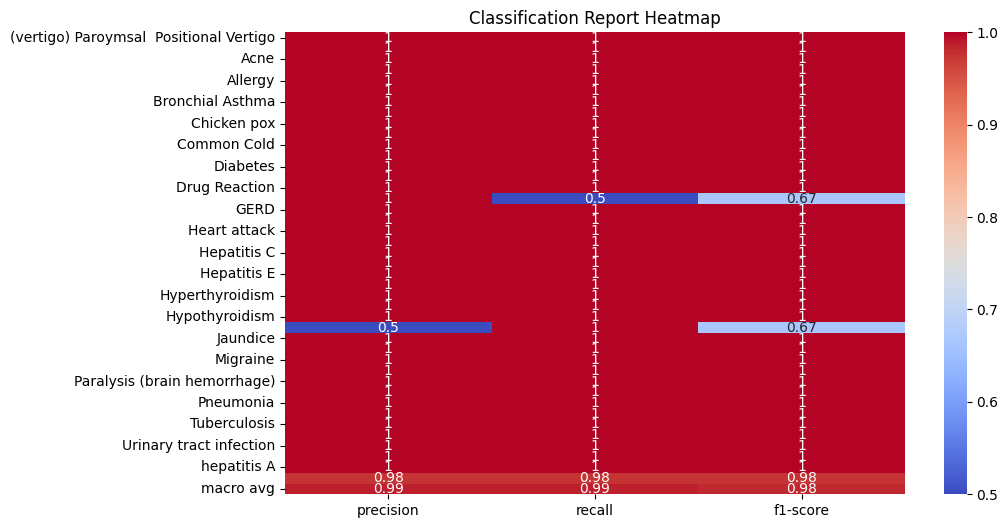

In [21]:
# 3. Classification Report - Convert report to DataFrame for plotting:

import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()

plt.figure(figsize=(10,6))
sns.heatmap(df.iloc[:-1, :-1], annot=True, cmap="coolwarm")
plt.title("Classification Report Heatmap")
plt.show()

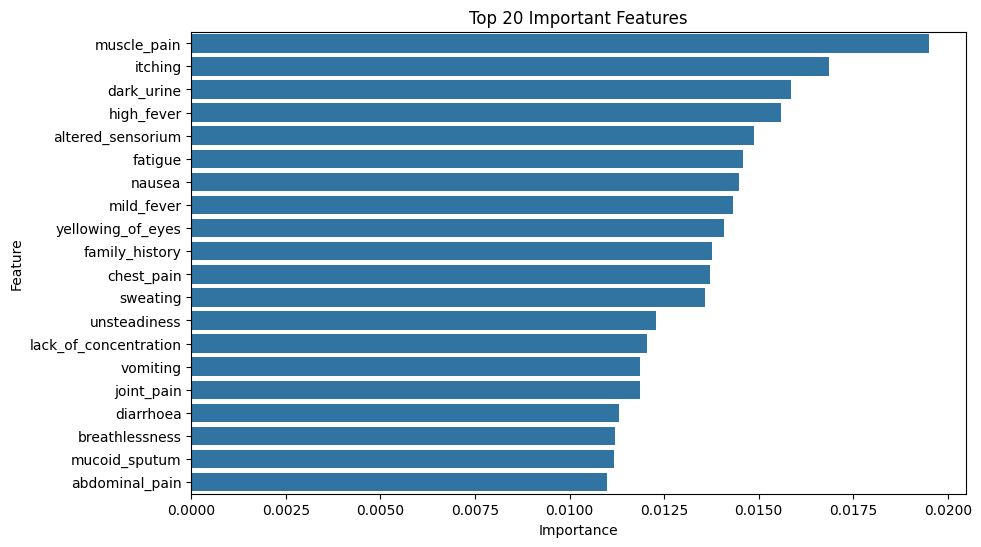

In [23]:
# 4. Feature Importance - This helps you understand which features are most important to your model.

import numpy as np

importances = model.feature_importances_
features = X_train.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Top 20 Important Features")
plt.show()

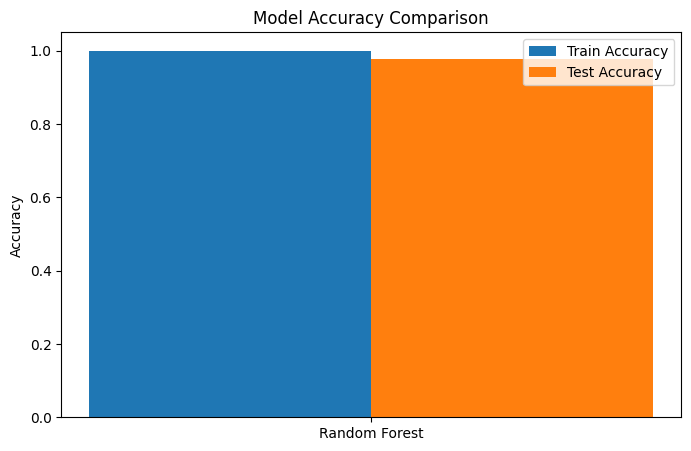

In [ ]:
# 5. Accuracy Comparison Graph - This helps you compare the performance of different models.

models = ["Random Forest"]
train_acc = [1.00]
test_acc = [0.9762]

x = range(len(models))

plt.figure(figsize=(8,5))
plt.bar(x, train_acc, width=0.4, label="Train Accuracy")
plt.bar([i + 0.4 for i in x], test_acc, width=0.4, label="Test Accuracy")

plt.xticks([i + 0.2 for i in x], models)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.legend()
plt.show()

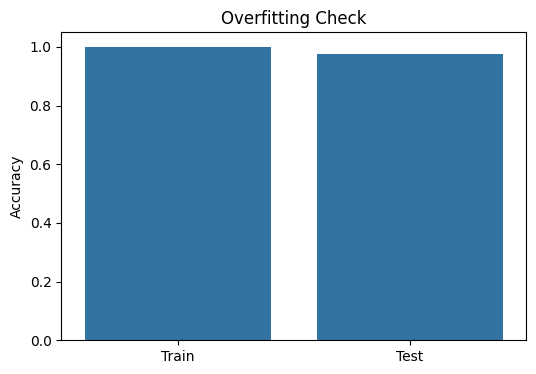

In [25]:
# 6. Overfitting Check Visualization - This helps you understand if your model is overfitting.
plt.figure(figsize=(6,4))
sns.barplot(x=["Train", "Test"], y=[1.0, 0.9762])
plt.title("Overfitting Check")
plt.ylabel("Accuracy")
plt.show()

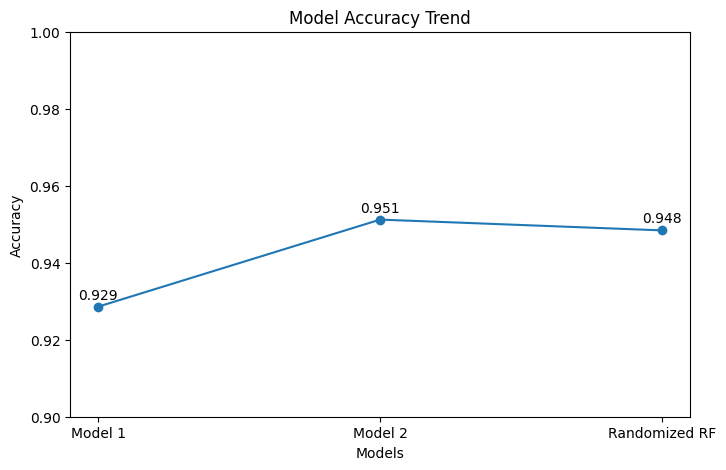

In [ ]:
# 7. Model Accuracy Trend - This helps you track the performance of your model over time. 
import matplotlib.pyplot as plt

models = ["Model 1", "Model 2", "Randomized RF"]
accuracies = [0.9286, 0.9512, 0.9484]

plt.figure(figsize=(8,5))
plt.plot(models, accuracies, marker='o')

plt.title("Model Accuracy Trend")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.0)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.show()